# Excess Permits Analysis

Compares estimated excess building permits (actual minus synthetic control)
with building damage estimates from the literature.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

OUTPUT_DIR = PROJECT_DIR / "output"
CONFIG_DIR = PROJECT_DIR / "config"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT files:", [p.name for p in OUTPUT_DIR.glob("*")])
print("CONFIG files:", [p.name for p in CONFIG_DIR.glob("*")])

# Load SCM diagnostics (generated by 05_synthetic_control.ipynb)
scm = pd.read_csv(PROJECT_DIR / 'output' / 'scm_diagnostics.csv')
print(f'SCM diagnostics: {len(scm)} places')
print(scm[['name', 'type', 'excess_permits', 'post_months']].head(10))

# Load building damage literature review
lit = pd.read_csv(PROJECT_DIR / 'config' / 'building_damage_literature.csv')
print(f'\nLiterature review: {len(lit)} rows')
print(lit[['Category', 'Disaster', 'Place']].head(10))

PROJECT_DIR: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo
OUTPUT files: ['bps_place_monthly_panel.csv', 'disaster_config.json', 'hurricane_places.csv', 'permits_panel.csv', 'placebo_fits.pkl', 'rmspe_ratios.csv', 'scm_diagnostics.csv', 'scm_fits.pkl']
CONFIG files: ['bps_metro_monthly_panel.csv', 'building_damage_literature.csv', 'fema_disasters_by_metro.csv', 'hurricane_place_selections.csv', 'nonhurr_place_selections.csv', 'place_exclusions.csv']
SCM diagnostics: 258 places
                                           name       type  excess_permits  \
0              Indian River Co. (unincorp.), FL  Hurricane     2417.273058   
1                             Ocean Springs, MS  Hurricane      -94.563298   
2                                     Foley, AL  Hurricane      351.963523   
3        Jefferson Davis Parish (unincorp.), LA  Hurricane       60.864531   
4                 Charlotte Co. (unincorp.), FL  Hurricane      -61.476055   
5  Escambia County Part Unincorporated Area, FL  Hur

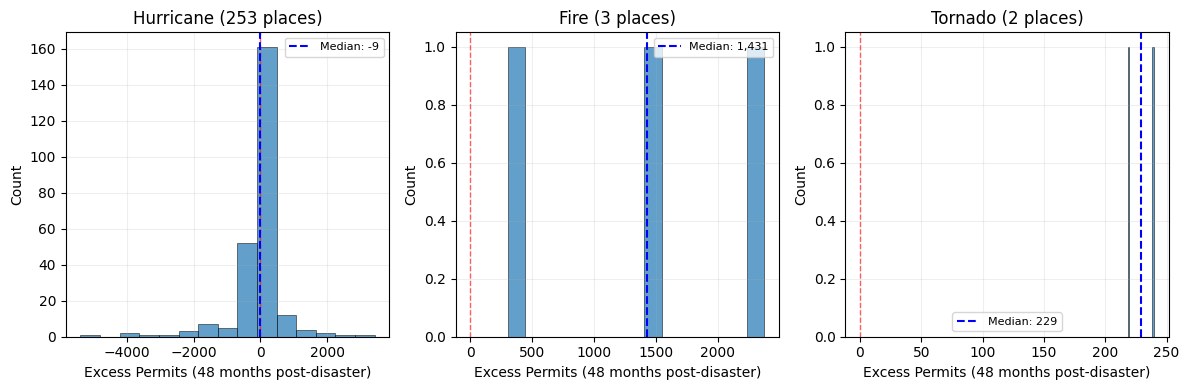

In [11]:
# ── Histograms of excess permits by disaster type ──

types_to_plot = ['Hurricane', 'Fire', 'Tornado']
fig, axes = plt.subplots(1, len(types_to_plot), figsize=(12, 4))

for ax, dtype in zip(axes, types_to_plot):
    subset = scm[scm['type'] == dtype]['excess_permits'].dropna()
    if len(subset) == 0:
        ax.text(0.5, 0.5, f'No data for {dtype}',
                transform=ax.transAxes, ha='center')
        continue
    ax.hist(subset, bins=15, edgecolor='k', linewidth=0.5, alpha=0.7)
    ax.axvline(0, color='red', linewidth=1, linestyle='--', alpha=0.6)
    ax.axvline(subset.median(), color='blue', linewidth=1.5, linestyle='--',
              label=f'Median: {subset.median():,.0f}')
    ax.set_xlabel('Excess Permits (48 months post-disaster)')
    ax.set_ylabel('Count')
    ax.set_title(f'{dtype} ({len(subset)} places)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [13]:
# ── Merge SCM excess permits into literature review table ──

def normalize_name(name):
    """Create a merge key from either SCM or lit review place names."""
    s = str(name).strip()
    # Extract state: handle both 'Name, ST' and 'Name (ST)' formats
    m_comma = re.match(r'^(.+),\s*([A-Z]{2})$', s)
    m_paren = re.match(r'^(.+)\s+\(([A-Z]{2})\)$', s)
    if m_comma:
        place, state = m_comma.group(1).strip(), m_comma.group(2)
    elif m_paren:
        place, state = m_paren.group(1).strip(), m_paren.group(2)
    else:
        return s.lower()
    # Normalize place name
    place = place.lower()
    place = place.replace('(unincorp.)', '').strip()
    place = place.replace(' par.', ' parish')
    place = place.replace(' co.', ' county')
    place = place.replace(' twp.', ' township')
    place = re.sub(r'\s+', ' ', place).strip()
    return f'{place}|{state.lower()}'

# Manual name overrides for known mismatches
LIT_OVERRIDES = {
    'Estero (FL)': 'estero village|fl',
    'Islamorada (FL)': 'islamorada village of islands|fl',
    'Escambia Co. (FL)': 'escambia county part unincorporated area|fl',
}

scm['merge_key'] = scm['name'].apply(normalize_name)
lit['merge_key'] = lit['Place'].apply(
    lambda x: LIT_OVERRIDES.get(str(x).strip(), normalize_name(x)))

# Check for duplicates in merge keys
scm_dupes = scm[scm['merge_key'].duplicated(keep=False)]
if len(scm_dupes) > 0:
    print('WARNING: Duplicate merge keys in SCM data:')
    print(scm_dupes[['name', 'merge_key']])

# Merge
merged = lit.merge(scm[['merge_key', 'excess_permits', 'post_months', 'rmspe_pct', 'mean_raw']],
                   on='merge_key', how='left')

# Report matches
n_matched = merged['excess_permits'].notna().sum()
n_unmatched = merged['excess_permits'].isna().sum()
print(f'Matched: {n_matched} / {len(merged)} literature review rows')
print(f'Unmatched: {n_unmatched} rows')

# Show unmatched literature rows
if n_unmatched > 0:
    print('\nUnmatched literature review places:')
    unmatched = merged[merged['excess_permits'].isna()][['Category', 'Disaster', 'Place', 'merge_key']]
    for _, row in unmatched.iterrows():
        print(f"  {row['Place']:<40s}  key: {row['merge_key']}")

# Show SCM places not in literature review
scm_only = scm[~scm['merge_key'].isin(lit['merge_key'])]
if len(scm_only) > 0:
    print(f'\nSCM places not in literature review ({len(scm_only)}):')
    for _, row in scm_only.iterrows():
        print(f"  {row['name']:<40s}  key: {row['merge_key']}")

Matched: 64 / 72 literature review rows
Unmatched: 8 rows

Unmatched literature review places:
  Ventura (CA)                              key: ventura|ca
  Ventura Co. (CA)                          key: ventura county|ca
  Malibu (CA)                               key: malibu|ca
  Paradise (CA)                             key: paradise|ca
  Butte Co. (CA)                            key: butte county|ca
  Louisville (CO)                           key: louisville|co
  Superior (CO)                             key: superior|co
  Boulder Co. (CO)                          key: boulder county|co

SCM places not in literature review (194):
  Indian River Co. (unincorp.), FL          key: indian river county|fl
  Foley, AL                                 key: foley|al
  Brevard Co. (unincorp.), FL               key: brevard county|fl
  Mobile Co. (unincorp.), AL                key: mobile county|al
  Palm Bay, FL                              key: palm bay|fl
  Volusia Co. (unincorp.), FL     

In [15]:
# ── Filter out excluded places ──
excl = pd.read_csv(PROJECT_DIR / 'config' / 'place_exclusions.csv')
# Only exclude places with full exclusions (no specific event), not event-specific ones
full_excl = excl[excl['event_name'].isna()]
excl_keys = set(full_excl['pseudo_name'].apply(
    lambda x: LIT_OVERRIDES.get(str(x).strip(), normalize_name(x))))
merged = merged[~merged['merge_key'].isin(excl_keys)].copy()
print(f'After excluding {len(excl_keys & set(merged["merge_key"]))} excluded places: '
      f'{len(merged)} rows remain')

# ── Display merged table ──

display_cols = ['Category', 'Disaster', 'Date', 'Place',
                '# of Destroyed Houses',
                'excess_permits', 'post_months', 'Reference']
out = merged[display_cols].copy()
out.columns = ['Category', 'Disaster', 'Date', 'Place',
               'Destroyed',
               'Excess_Permits', 'Post_Months', 'Reference']

# Save merged table
csv_path = PROJECT_DIR / 'output' / 'damage_vs_excess_permits.csv'
out['Excess_Permits'] = out['Excess_Permits'].round(0).astype('Int64')
out.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

out

After excluding 0 excluded places: 67 rows remain
Saved: C:\Users\Lenovo\bps_dnsc_repo\bps-dnsc-repo\output\damage_vs_excess_permits.csv


,Category,Disaster,Date,Place,Destroyed,Excess_Permits,Post_Months,Reference
0,Wildfire,Tubbs Fire,2017-10,Santa Rosa (CA),3043,2378,48.0,https://www.srcity.org/DocumentCenter/View/242...
1,Wildfire,Tubbs Fire,2017-10,Sonoma Co. (CA),5636,1431,48.0,https://www.fire.ca.gov/incidents/2017/10/8/tu...
4,Wildfire,Woolsey Fire,2018-11,Malibu (CA),488,<NA>,NaN,https://malibupermits.ci.malibu.ca.us/WoolseyR...
7,Wildfire,Marshall Fire,2021-12,Louisville (CO),550,<NA>,NaN,https://bouldercounty.gov/news/boulder-county-...
9,Wildfire,Marshall Fire,2021-12,Boulder Co. (CO),156,<NA>,NaN,https://bouldercounty.gov/news/boulder-county-...
...,...,...,...,...,...,...,...,...
67,Hurricane,Ian,2022-09,Estero (FL),NaN,295,37.0,NaN
68,Hurricane,Ian,2022-09,Fort Myers (FL),NaN,-3770,48.0,NaN
69,Hurricane,Ian,2022-09,Fort Myers Beach (FL),900,-51,48.0,https://www.nhc.noaa.gov/data/tcr/AL092022_Ian...
70,Hurricane,Ian,2022-09,Lee Co. (FL),5369,3416,48.0,https://www.nhc.noaa.gov/data/tcr/AL092022_Ian...


In [17]:
# ── Generate LaTeX summary table ──

def fmt_source(ref):
    """Extract first URL from reference and wrap in \\url{}."""
    if pd.isna(ref) or str(ref).strip() == '':
        return ''
    ref = str(ref).strip()
    # Extract first URL
    m = re.search(r'(https?://\S+)', ref)
    if m:
        url = m.group(1)
        return r'\url{' + url + '}'
    return ref  # fallback: return raw text

# Build table data from merged (use 'out' from previous cell)
tbl = out[['Place', 'Disaster', 'Excess_Permits', 'Destroyed', 'Reference']].copy()
tbl['Source'] = tbl['Reference'].apply(fmt_source)

# Format destroyed column
def fmt_destroyed(v):
    if pd.isna(v) or str(v).strip() == '':
        return '---'
    s = str(v).strip().replace(',', '')
    try:
        return f'{int(s):,}'
    except ValueError:
        return str(v)  # e.g. "30% destroyed"

tbl['Destroyed_fmt'] = tbl['Destroyed'].apply(fmt_destroyed)

# Format excess permits
def fmt_excess(v):
    if pd.isna(v):
        return '---'
    return f'{int(v):,}'

tbl['E_fmt'] = tbl['Excess_Permits'].apply(fmt_excess)

# Generate LaTeX
lines = []
lines.append(r'\begin{landscape}')
lines.append(r'{\footnotesize')
lines.append(r'\begin{longtable}{llrrp{10cm}}')
lines.append(r'\caption{Excess building permits and reported structures destroyed for disaster-affected places.}\label{tab:excess_permits} \\')
lines.append(r'\toprule')
lines.append(r'Place & Disaster & $E$ & Destroyed & Source \\')
lines.append(r'\midrule')
lines.append(r'\endfirsthead')
lines.append(r'\toprule')
lines.append(r'Place & Disaster & $E$ & Destroyed & Source \\')
lines.append(r'\midrule')
lines.append(r'\endhead')
lines.append(r'\bottomrule')
lines.append(r'\endfoot')

for _, row in tbl.iterrows():
    place = str(row['Place']).replace('&', r'\&')
    disaster = str(row['Disaster']).replace('&', r'\&')
    source = row['Source']
    lines.append(f'{place} & {disaster} & {row["E_fmt"]} & {row["Destroyed_fmt"]} & {source} \\\\')

lines.append(r'\end{longtable}')
lines.append(r'}')
lines.append(r'\end{landscape}')

latex_str = '\n'.join(lines)
print(latex_str)

# Save to file
tex_path = PROJECT_DIR / 'output' / 'table_excess_permits.tex'
with open(tex_path, 'w') as f:
    f.write(latex_str)
print(f'\nSaved: {tex_path}')

\begin{landscape}
{\footnotesize
\begin{longtable}{llrrp{10cm}}
\caption{Excess building permits and reported structures destroyed for disaster-affected places.}\label{tab:excess_permits} \\
\toprule
Place & Disaster & $E$ & Destroyed & Source \\
\midrule
\endfirsthead
\toprule
Place & Disaster & $E$ & Destroyed & Source \\
\midrule
\endhead
\bottomrule
\endfoot
Santa Rosa (CA) & Tubbs Fire & 2,378 & 3,043 & \url{https://www.srcity.org/DocumentCenter/View/24254/Summary-of-Residential-Destruction-Resulting-from-October-2017-Wildfires_41919} \\
Sonoma Co. (CA) & Tubbs Fire & 1,431 & 5,636 & \url{https://www.fire.ca.gov/incidents/2017/10/8/tubbs-fire-central-lnu-complex} \\
Malibu (CA) & Woolsey Fire & --- & 488 & \url{https://malibupermits.ci.malibu.ca.us/WoolseyRebuildStats.aspx?returnId=901} \\
Louisville (CO) & Marshall Fire & --- & 550 & \url{https://bouldercounty.gov/news/boulder-county-releases-updated-list-of-structures-damaged-and-destroyed-in-the-marshall-fire/} \\
Boulder Co. (